In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/bank_churn_clean.csv")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

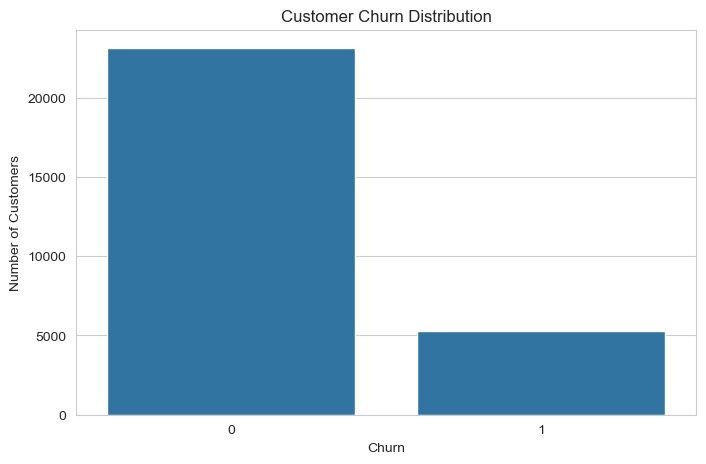

In [2]:
sns.countplot(data=df, x="churn")

plt.title("Customer Churn Distribution")

plt.xlabel("Churn")

plt.ylabel("Number of Customers")

plt.show()

In [3]:
churn_rate = df["churn"].value_counts(normalize=True) * 100

print(churn_rate)

churn
0    81.467127
1    18.532873
Name: proportion, dtype: float64


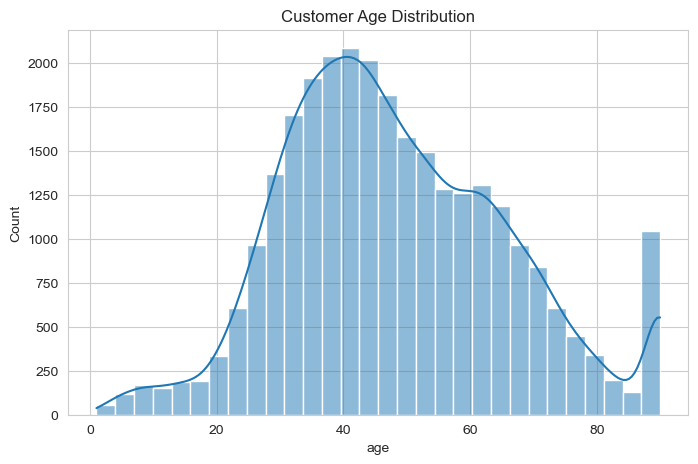

In [4]:
sns.histplot(df["age"], bins=30, kde=True)

plt.title("Customer Age Distribution")

plt.show()

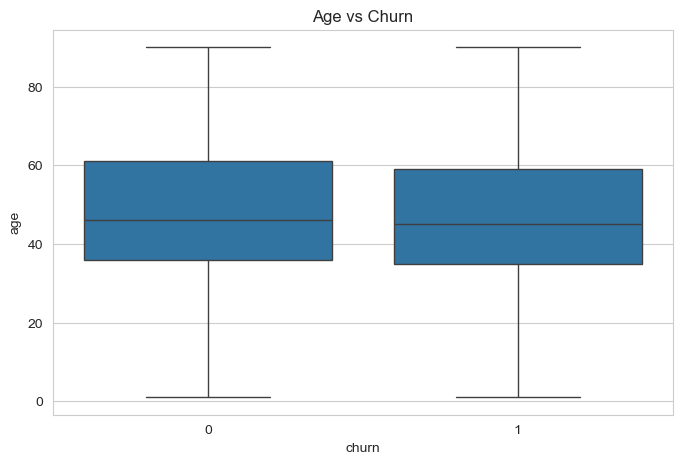

In [5]:
sns.boxplot(data=df, x="churn", y="age")

plt.title("Age vs Churn")

plt.show()

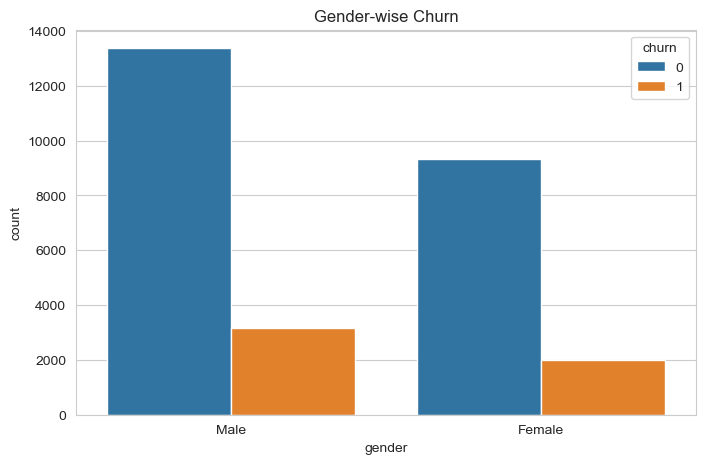

In [6]:
sns.countplot(data=df, x="gender", hue="churn")

plt.title("Gender-wise Churn")

plt.show()

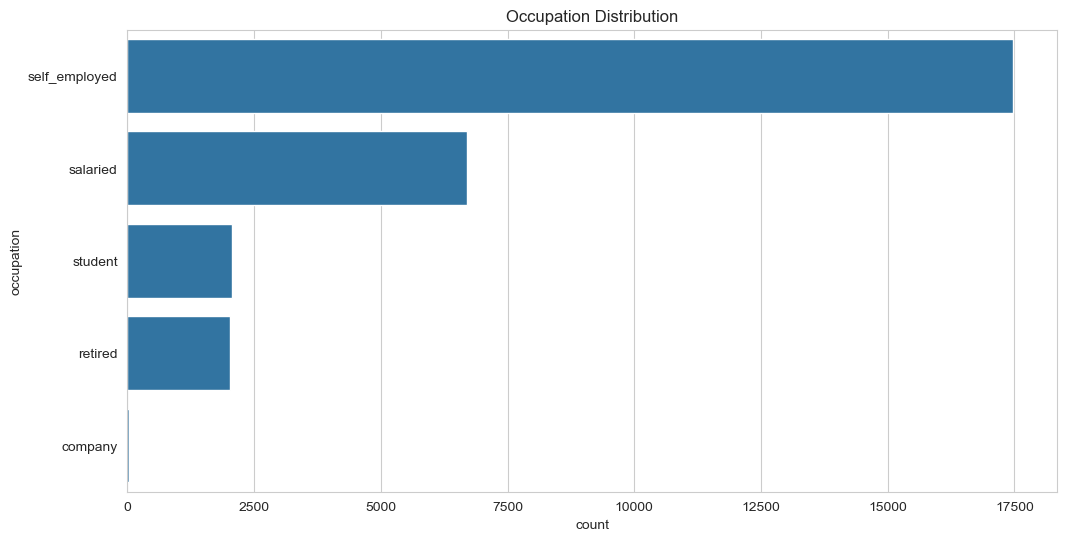

In [7]:
plt.figure(figsize=(12,6))

sns.countplot(data=df,

              y="occupation",

              order=df["occupation"].value_counts().index)

plt.title("Occupation Distribution")

plt.show()

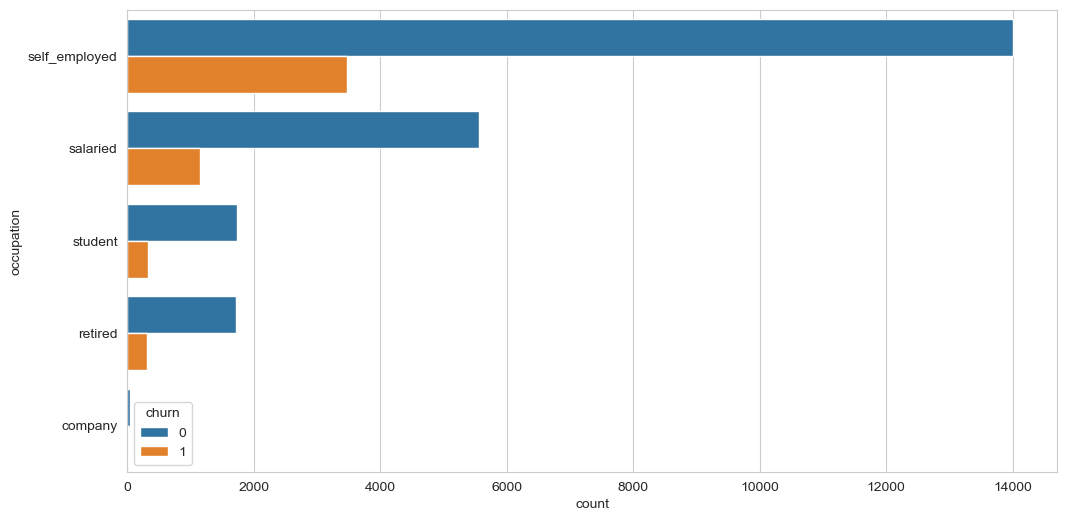

In [8]:
plt.figure(figsize=(12,6))

sns.countplot(data=df,

              y="occupation",

              hue="churn",

              order=df["occupation"].value_counts().index)

plt.show()

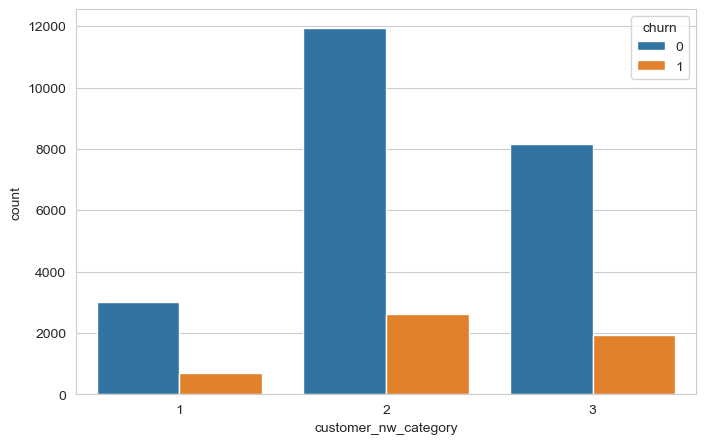

In [9]:
sns.countplot(data=df,

              x="customer_nw_category",

              hue="churn")

plt.show()

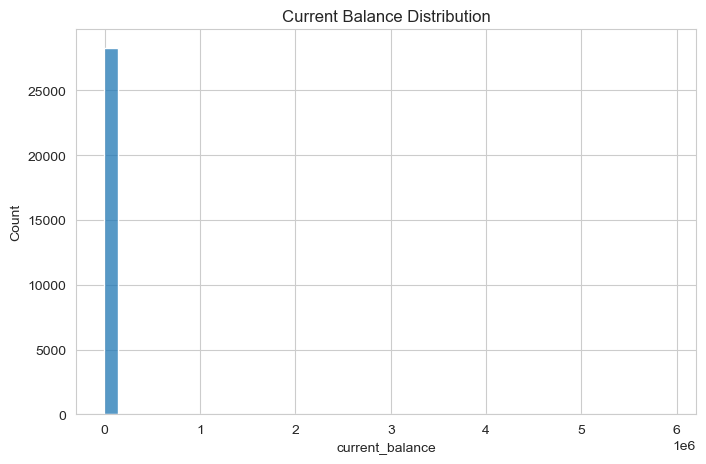

In [10]:
sns.histplot(df["current_balance"], bins=40)

plt.title("Current Balance Distribution")

plt.show()

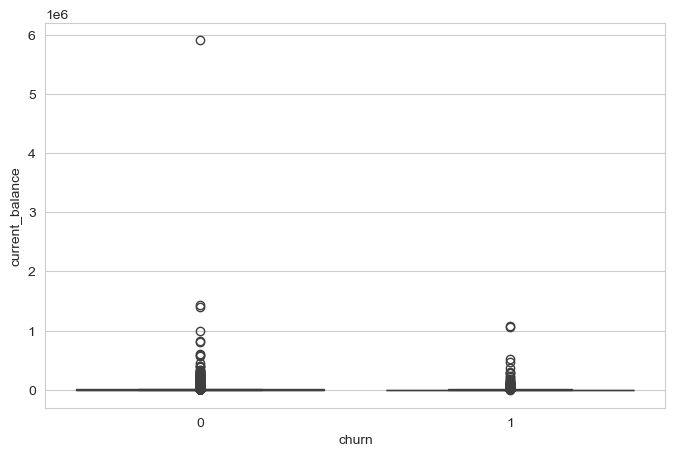

In [11]:
sns.boxplot(data=df,

            x="churn",

            y="current_balance")

plt.show()

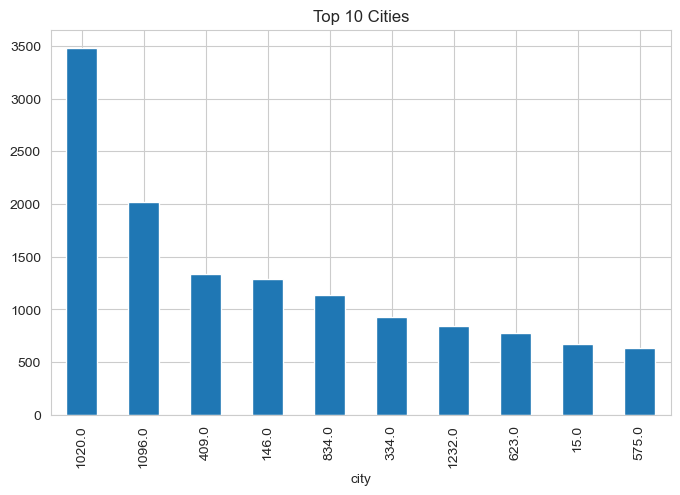

In [12]:
top_city = df["city"].value_counts().head(10)

top_city.plot(kind="bar")

plt.title("Top 10 Cities")

plt.show()

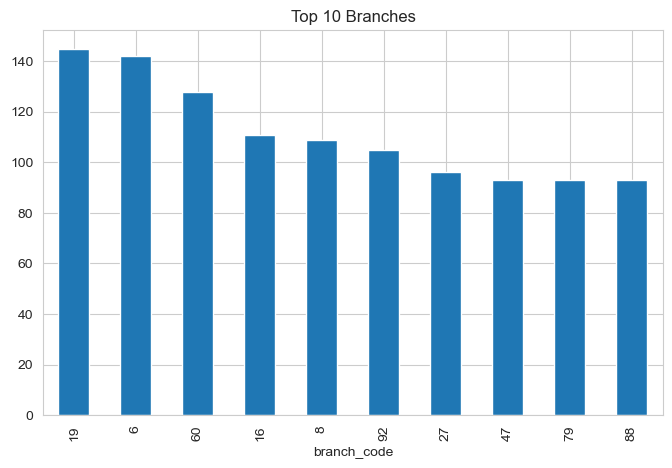

In [13]:
top_branch = df["branch_code"].value_counts().head(10)

top_branch.plot(kind="bar")

plt.title("Top 10 Branches")

plt.show()

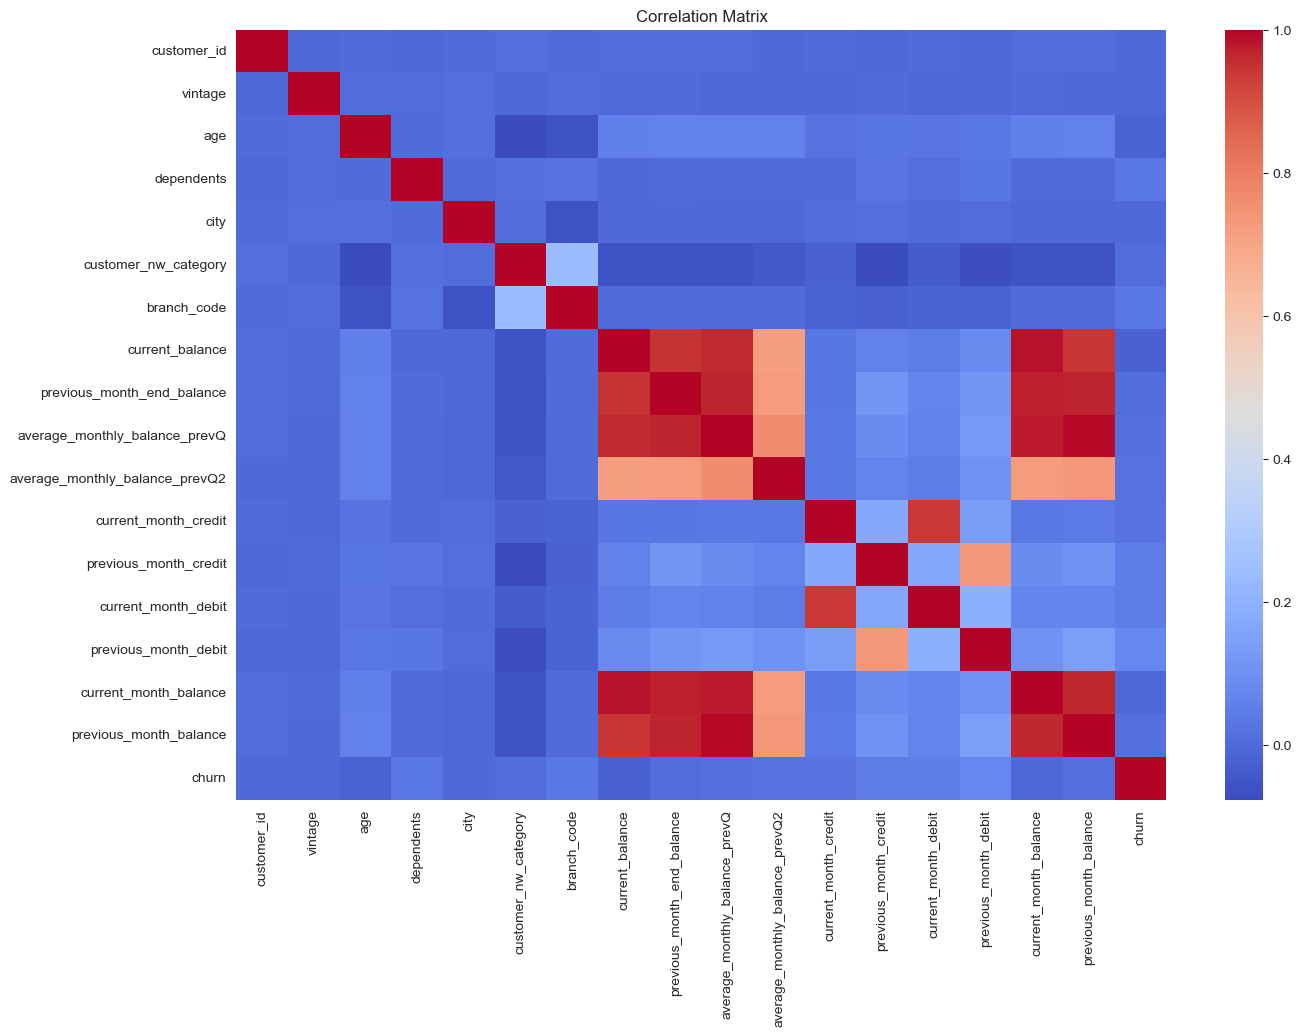

In [14]:
numeric = df.select_dtypes(include="number")

plt.figure(figsize=(15,10))

sns.heatmap(numeric.corr(),

            cmap="coolwarm",

            annot=False)

plt.title("Correlation Matrix")

plt.show()

In [15]:
corr = numeric.corr()["churn"].sort_values(ascending=False)

print(corr)

churn                             1.000000
previous_month_debit              0.073058
current_month_debit               0.048041
previous_month_credit             0.042179
branch_code                       0.035469
dependents                        0.033487
current_month_credit              0.020755
average_monthly_balance_prevQ2    0.018376
previous_month_balance            0.014593
average_monthly_balance_prevQ     0.011960
previous_month_end_balance        0.006886
customer_nw_category              0.006551
city                             -0.001585
customer_id                      -0.002723
vintage                          -0.004769
current_month_balance            -0.006391
age                              -0.020012
current_balance                  -0.024181
Name: churn, dtype: float64


Customers with higher debit transactions in the previous month exhibit a slightly higher tendency to churn, suggesting that recent transaction behavior may provide early warning signals for customer attrition.

Although age is commonly assumed to influence churn, the correlation analysis indicates a negligible linear relationship in this dataset.

High balance customers aren't necessarily more loyal.

Customers with unusual spending patterns might be leaving.

In [16]:
df.drop(columns=["customer_id"], inplace=True)

In [17]:
df["balance_change"] = (
    df["current_balance"] -
    df["previous_month_end_balance"]
)

In [18]:
df["credit_change"] = (
    df["current_month_credit"] -
    df["previous_month_credit"]
)

In [19]:
df["debit_change"] = (
    df["current_month_debit"] -
    df["previous_month_debit"]
)

In [20]:
df["total_transaction"] = (
    df["current_month_credit"] +
    df["current_month_debit"]
)

In [21]:
df["balance_ratio"] = (
    df["current_balance"] /
    (df["average_monthly_balance_prevQ"] + 1)
)